# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [2]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

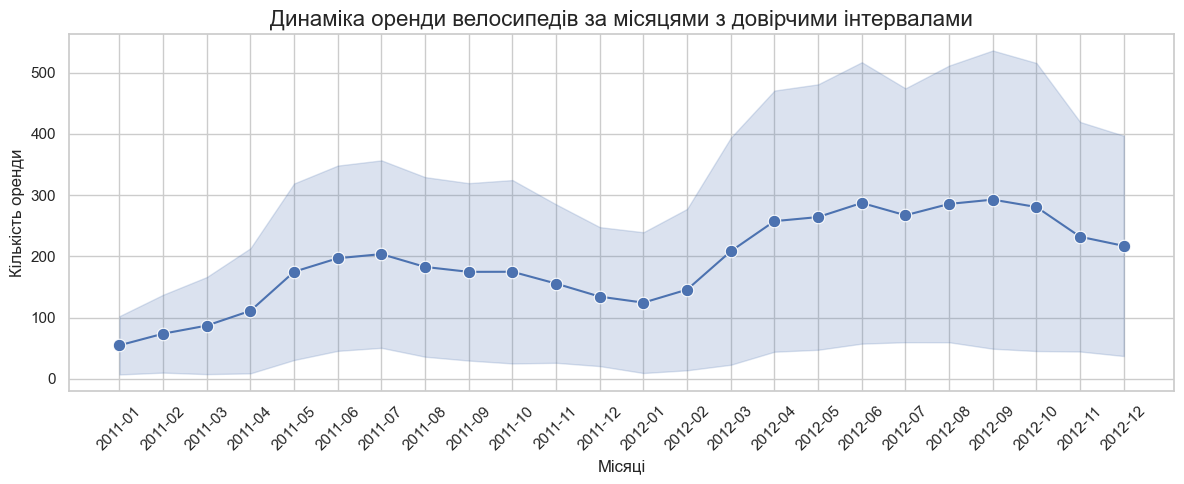

In [3]:
plt.figure(figsize=(12, 5))
sns.lineplot(df, x='month_year', y='count', errorbar='sd', marker='o', markersize=9)
plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами', fontsize=16)
plt.xlabel('Місяці')
plt.ylabel('Кількість оренди')
plt.xticks(rotation=45)
plt.tight_layout();

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

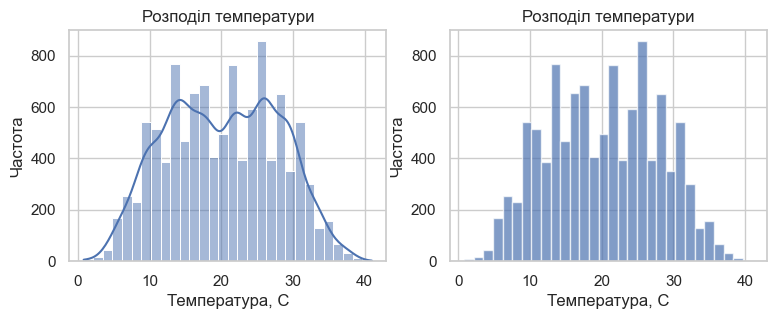

In [9]:
plt.figure(figsize=(9, 3))

plt.subplot(1, 2, 1)
sns.histplot(df, x='temp', bins=30, kde=True)
plt.title('Розподіл температури')
plt.xlabel('Температура, С')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
df['temp'].plot.hist(
    bins=30,
    alpha=0.7,
    edgecolor='white',
    title='Розподіл температури',
    xlabel='Температура, С',
    ylabel='Частота',
);

1. Візуально гістограми подібні, лише колір у Seaborn прозоріший та світліший
2. Додаткова лінія - це оцінка густини розподілу у вигляді кривої, яка згладжує стовпці гістограми. При зміні кількості бінів - також змінює свою конфігурацію.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

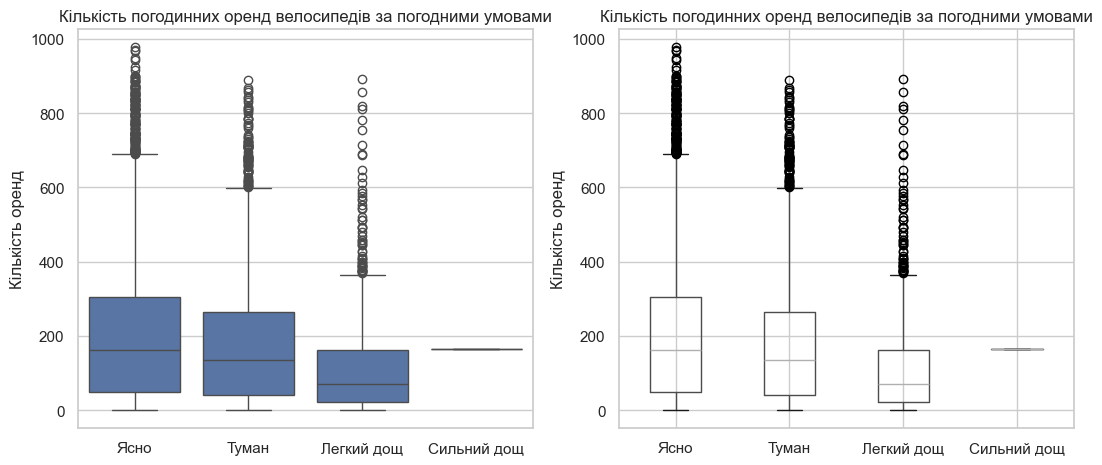

In [49]:
labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']
plt.figure(figsize=(11, 5))

ax1 = plt.subplot(1, 2, 1)
sns.boxplot(data=df, y='count', x='weather', ax=ax1)
ax1.set_title('Кількість погодинних оренд велосипедів за погодними умовами')
ax1.set_ylabel('Кількість оренд')
ax1.set_xlabel('')
ax1.set_xticks(range(0, 4))
ax1.set_xticklabels(["Ясно", "Туман", "Легкий дощ", "Сильний дощ"])

ax2 = plt.subplot(1, 2, 2)
df.boxplot(column='count', by='weather', ax=ax2)
ax2.set_title('Кількість погодинних оренд велосипедів за погодними умовами')
ax2.set_xlabel('')
ax2.set_xticks(range(1, 5))
ax2.set_xticklabels(["Ясно", "Туман", "Легкий дощ", "Сильний дощ"])
ax2.set_ylabel('Кількість оренд')

plt.suptitle('')
plt.tight_layout()

Графік, подубований з Seaborn одразу має кольорову заливку боксів, та є більш читабельним, бо фігури розташовані ближче одна до одної (щільніше). Графік з Pandas не має заливки (проглядають лінії сітки), що одразу зменшує його сприйняття, додані вертикальні лінії сітки (нерівномірно), фігури розташовані далі одна від одної, що також ускладнює сприйняття у порівнянні із графіком ліворуч.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [54]:
correlation = df[['season', 'holiday', 'workingday', 'weather', 
'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 
'count', 'day', 'week', 'weekday_num', 'year', 'month', 'hour']].corr()

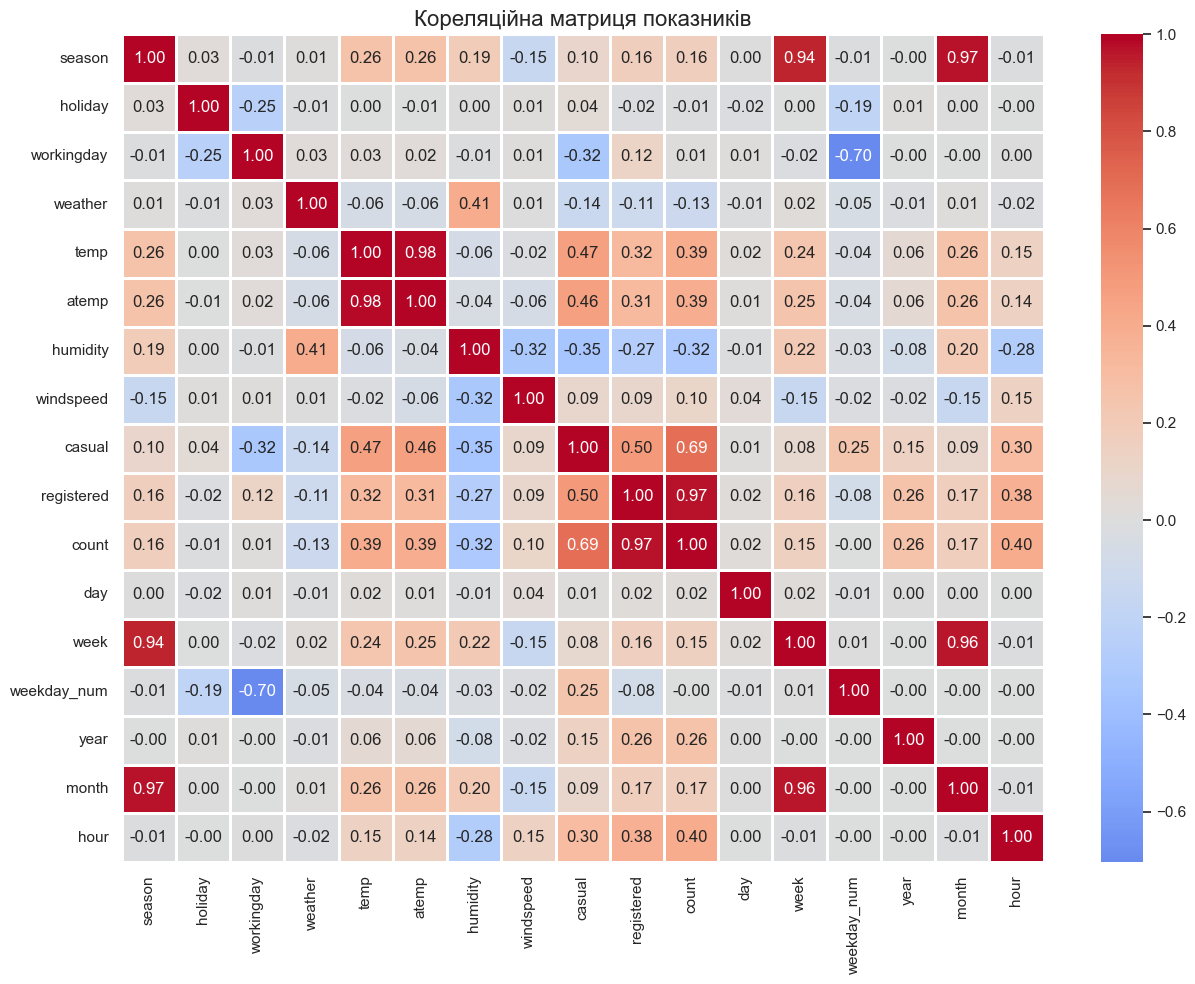

In [65]:
plt.figure(figsize=(13, 10))

sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=False, linewidths=1
            )

plt.title('Кореляційна матриця показників', fontsize=16)
plt.tight_layout()
plt.show()

1. Із загальною кількістю оренди (count) найбільше корелюють стовпці Registered (0.97), Casual (0.69), та по 0.4 - temp, atemp, hour? Тобто, чим більше користувачів (краще зареєстрованих), тим більшим буде значення оренди.
2. Між temp та atemp практично 100%-ва кореляція, а саме 0.98, це означає, що одна зі змінних практично повістю залежить від іншої (вони будуть змінюватися однаково), тому краще залишити лише одну з них.
3. Негативну кореляцію мають weekday_num та workingday (-0.7) - тут складно знайти логічний звʼязок між ними в контексті пояснення динаміки оренди; інші змінні мають набагато менше значення кореляції (від -0.28 до -0.35), це повʼязані між собою погодні характеристики швидкості вітру та вологості, часу доби та вологості; а також вологості та кількості зареєстрованих та інших користувачів, і сама кількість оренди. Логічним є зменшення кількості користувачів та поїздок при збільшенні вологості повітря.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


In [86]:
df['quarter'] = df.index.quarter
df['year_quarter'] = 'Q' + df['quarter'].astype(str) + ' ' + df['year'].astype(str)

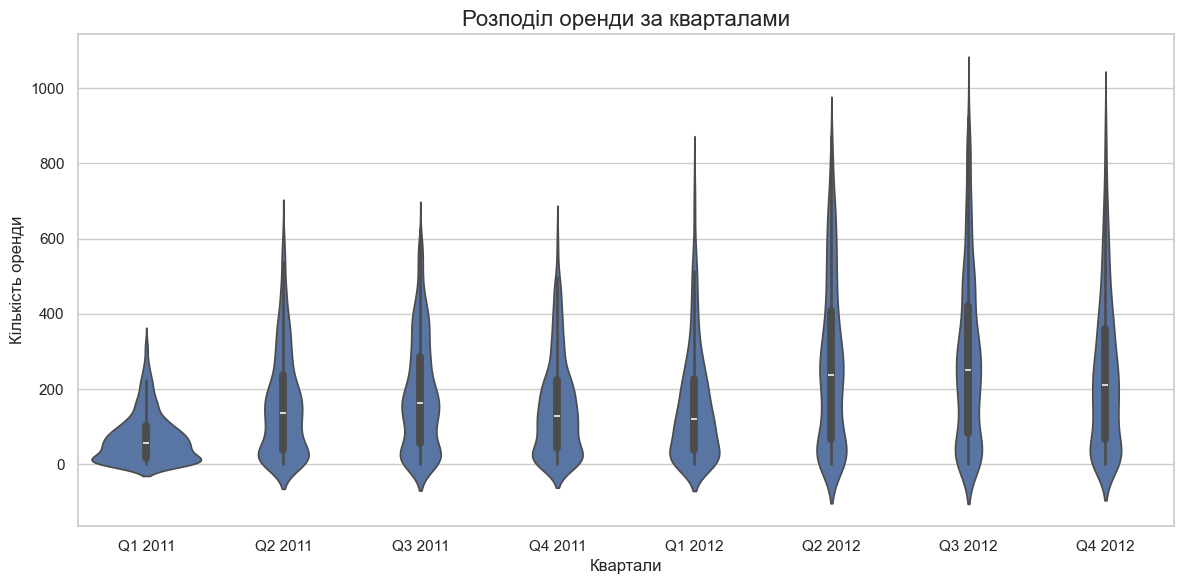

In [92]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='year_quarter', y='count')
plt.title('Розподіл оренди за кварталами', fontsize=16)
plt.xlabel('Квартали')
plt.ylabel('Кількість оренди')
plt.tight_layout()
plt.show()

1. "Товщина" violin plot показує подвійну найбільшу частоту розподілу (бо ліва і права частини "скрипки" симетричні - це перевернуті згладжені гістограми).
2. Найбільша варіабельність оренди спостерігається в 3-му кварталі 2012 року, там найбільша висота "скрипки".
3. Перевага violin plot над звичайним box plot в тому, що бачимо розподіл кожної категорії більш наочно, бо зображено саму гістограму, щоправда в перегорнутому вигляді.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

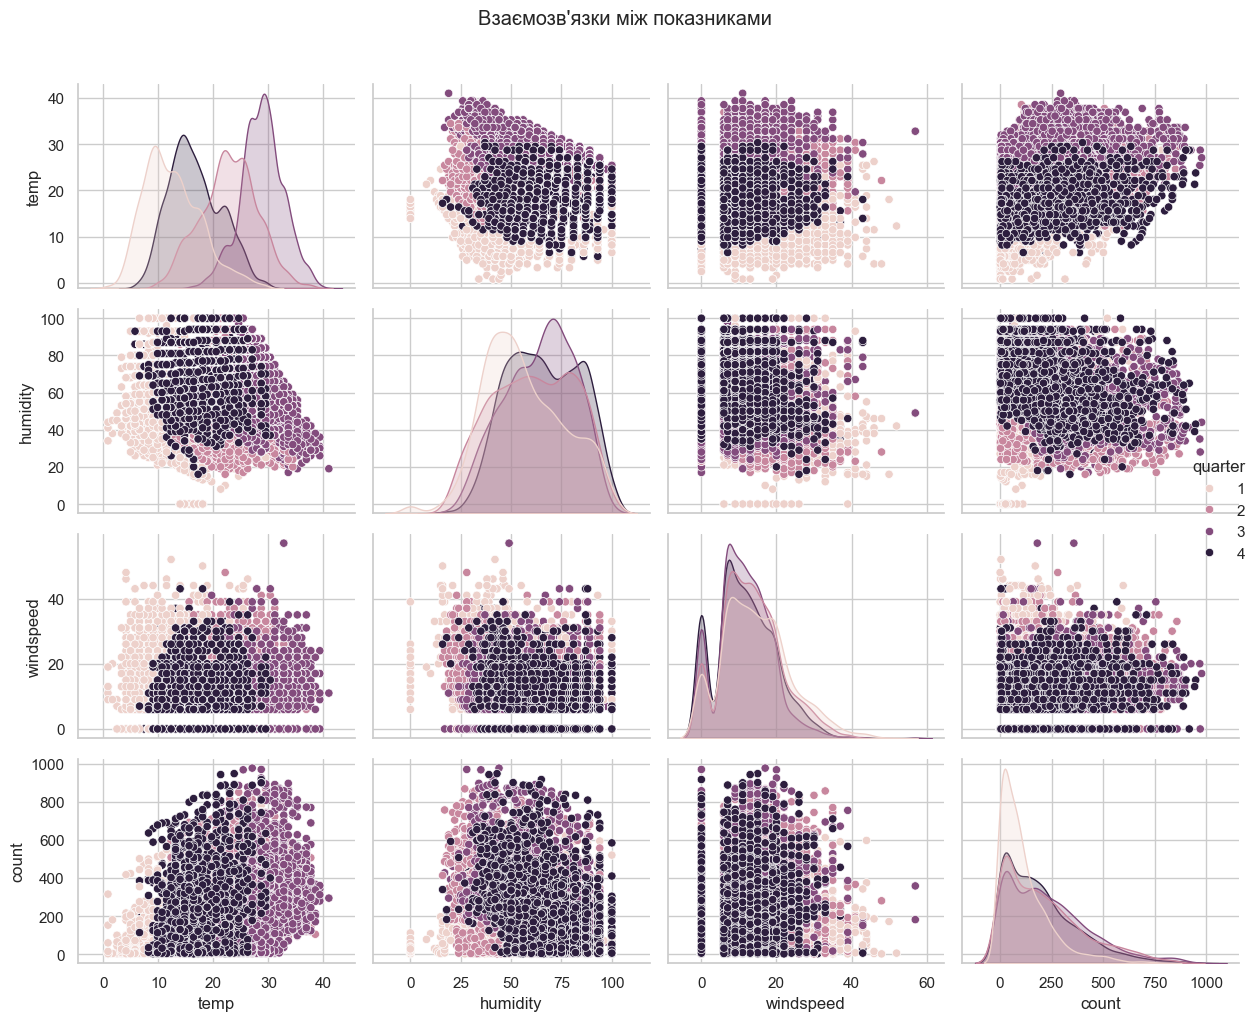

In [96]:
sample_df = df[['temp', 'humidity', 'windspeed', 'count', 'quarter']]
sns.pairplot(sample_df, height=2.5, aspect=1.2, hue='quarter')
plt.suptitle('Взаємозв\'язки між показниками', y=1.02)
plt.tight_layout()
plt.show()

1. Найсильніший лінійний зв'язок спостерігається між змінними Count та Temp, чим більша температура - тим більша кількість оренди.
2. Найбільше між кварталами відрізняється температура, всі 4 криві найбільше не співпадають одна з одною з-поміж інших характеристик. Найменше за кварталами відрізняється швидкість вітру, а також кількість оренди(за виключенням 1-го кварталу).

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

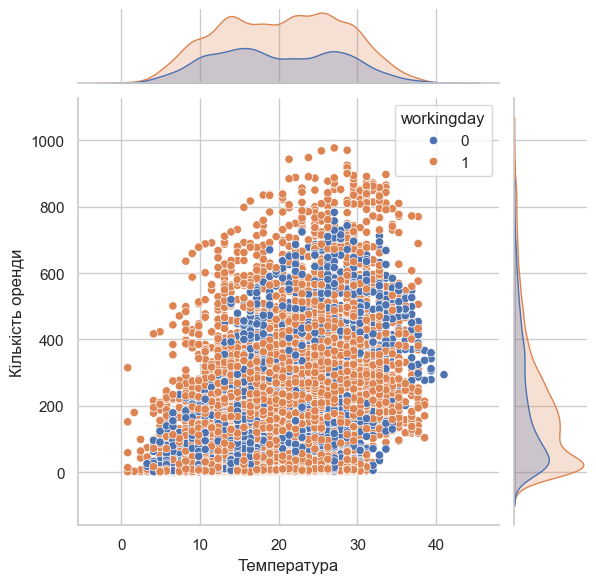

In [98]:
sns.jointplot(data=df, x="temp", y="count", hue="workingday")
plt.xlabel('Температура')
plt.ylabel('Кількість оренди');

1. Графіки по краях - це згладжені гістограми розподілів температури за вихідними та святклвими днями, та кількості оренди за вихідними та святковими днями.
2. Чи є різниця у поведінці користувачів у робочий і неробочий день? Для робочих днів більш чітко виражена залежність оренди від температури, щодо вихідних, то тут такий звʼязок проявлено слабко. Втім, у вихідні дні більш чіткою є концентрація кількості оренди навколо проміжку 200-400 одиниць, а для робочих днів кількість практично рівномірно розподілена по всьому діапазону від 0 до 600 одиниць. Що і підтверджується гістограмою - для робочих днів кількість оренди практично ідеальна bell-curve, а для вихідних - є провал.